In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
import xarray as xr

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from neuralop.models import UNO

torch.serialization.add_safe_globals([torch.nn.functional.gelu])

In [2]:
CURRENT_DIRECTORY = f'horizontal_correct/'
DATA_PATH = f'data'
ASSETS_PATH = f'assets'
MODELS_PATH = f'models'

filepaths = [f'{DATA_PATH}/source_{i}.hdf5' for i in range(1, 4)]

dim_map = {
    'phony_dim_0' : 'time',
    'phony_dim_1' : 'sample',
    'phony_dim_2' : 'channel',
    'phony_dim_3' : 'Y',
    'phony_dim_4' : 'X'
}

In [3]:
def preprocess(path):
    print(f'Открытие датасета : {path}')
    ds = xr.open_dataset(path, engine='h5netcdf', phony_dims='sort').rename(dim_map)
    pressure = ds.dataset.isel(channel=0)
    source = ds.source
    return xr.Dataset({'pressure': pressure, 'source':source}, attrs=ds.attrs)

print("Загрузка данных...")
processed_datasets = [preprocess(f) for f in filepaths]
final_ds = xr.concat(processed_datasets, dim='sample').squeeze('phony_dim_5')

Загрузка данных...
Открытие датасета : data/source_1.hdf5
Открытие датасета : data/source_2.hdf5
Открытие датасета : data/source_3.hdf5


In [ ]:
raw_p = final_ds.pressure.values
mask_2d = ~np.isnan(raw_p[0, 0])

p_min, p_max = np.nanmin(raw_p), np.nanmax(raw_p)
norm_p = np.zeros_like(raw_p, dtype='float32')
norm_p[:, :, mask_2d] = (raw_p[:, :, mask_2d] - p_min) / (p_max - p_min)

s_raw = final_ds.source.values.copy()
s_raw[..., ~mask_2d] = 0 
s_abs_max = np.max(np.abs(s_raw))
norm_s = (s_raw / s_abs_max).astype('float32') if s_abs_max != 0 else s_raw

In [5]:
P_tensor = torch.from_numpy(norm_p).permute(1, 0, 2, 3).float()
S_tensor = torch.from_numpy(norm_s).float()
X_final = torch.stack([P_tensor, S_tensor], dim=2)
STATIC_MASK = torch.from_numpy(mask_2d.astype('float32'))

In [6]:
def get_indices(size, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    np.random.seed(2318)
    indices = np.arange(size)
    np.random.shuffle(indices)
    train_end = int(size * train_ratio)
    val_end = train_end + int(size * val_ratio)
    return indices[:train_end], indices[train_end:val_end], indices[val_end:]

In [7]:
class SpatiotemporalDataset(Dataset):
    def __init__(self, data, indices):
        self.data = data[indices] 
        self.N_samples = self.data.shape[0]
        self.T_total = self.data.shape[1]
        self.T_future = self.T_total - 1

    def __len__(self):
        return self.N_samples

    def __getitem__(self, idx):
        p_init = self.data[idx, 0, 0] 
        p_init_cube = p_init.unsqueeze(0).repeat(self.T_future, 1, 1)
        
        s_future_cube = self.data[idx, 1:, 1]
        
        x = torch.stack([p_init_cube, s_future_cube], dim=0)
        
        y = self.data[idx, 1:, 0].unsqueeze(0)
        
        return x, y

In [13]:
def train_model(modes, scalings, out_channels, train_loader, val_loader, device, static_mask, epochs=250):
    
    model = UNO(
        in_channels=2, 
        out_channels=1,
        domain_padding=0.1,
        non_linearity=torch.nn.functional.gelu,
        hidden_channels=32, 
        n_layers=4,
        projection_channels=32,
        uno_out_channels=out_channels,
        uno_n_modes=modes,
        uno_scalings=scalings,
        channel_mlp_skip="linear"
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3) 
    
    mask = static_mask.to(device).float()
    mask_3d = mask.unsqueeze(0).unsqueeze(0).unsqueeze(0) 

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    best_val_l2 = float('inf')
    best_model_path = "uno_3d_best.pth"
    patience_counter = 0

    train_losses, val_losses_mean = [], []
    print(f"=== START 3D TRAINING | Device: {device} ===")

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            x_in, y_true = [b.to(device) for b in batch]
            optimizer.zero_grad()
            
            pred = model(x_in) 
            
            loss = criterion(pred * mask_3d, y_true * mask_3d)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item() * x_in.size(0)
            
        epoch_train_loss = total_train_loss / len(train_loader.dataset)

        model.eval()
        val_l2_errors = []
        with torch.no_grad():
            for batch_v in val_loader:
                x_v, y_v = [b.to(device) for b in batch_v]
                pred_v = model(x_v) * mask_3d
                true_v = y_v * mask_3d
                
                preds_flat = pred_v.reshape(x_v.size(0), -1)
                trues_flat = true_v.reshape(x_v.size(0), -1)
                diff_norm = torch.norm(preds_flat - trues_flat, p=2, dim=1)
                true_norm = torch.norm(trues_flat, p=2, dim=1)
                rel_l2 = (diff_norm / torch.clamp(true_norm, min=1e-8)) * 100
                val_l2_errors.extend(rel_l2.cpu().numpy())

        epoch_mean = np.mean(val_l2_errors)
        scheduler.step(epoch_mean) 
        
        current_lr = optimizer.param_groups[0]['lr']
        if epoch_mean < best_val_l2:
            best_val_l2 = epoch_mean
            torch.save(model.state_dict(), best_model_path)
            status = "<--- save"
            patience_counter = 0
        else:
            status = f"[Wait {patience_counter+1}]"
            patience_counter += 1
            
        print(f"Epoch {epoch+1:03d} | LR: {current_lr:.2e} | Train Loss: {epoch_train_loss:.6f} | Val L2: {epoch_mean:.2f}% {status}")

        if patience_counter >= 30:
            print("=== EARLY STOPPING ===")
            break

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    return model

In [9]:
def analyze_results(model, test_loader, device, static_mask, num_plots=2):
    model.eval()
    mask_3d = static_mask.to(device).float().unsqueeze(0).unsqueeze(0).unsqueeze(0)
    
    global_errors = []
    well_errors = []
    plots_done = 0

    print("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ НА ТЕСТЕ ===")
    with torch.no_grad():
        for batch in test_loader:
            x_in, y_true = [b.to(device) for b in batch]
            pred = model(x_in) * mask_3d
            true = y_true * mask_3d
            
            wells_cube = x_in[:, 1:2] 
            well_mask = (torch.abs(wells_cube) > 1e-5).float() * mask_3d
            
            for i in range(x_in.shape[0]):
                p_p = pred[i]
                p_t = true[i]
                w_m = well_mask[i]
                
                g_err = (torch.norm(p_p - p_t) / torch.norm(p_t)) * 100
                global_errors.append(g_err.item())
                
                if w_m.sum() > 0:
                    w_err = (torch.norm((p_p - p_t)*w_m) / torch.norm(p_t*w_m)) * 100
                    well_errors.append(w_err.item())

                if plots_done < num_plots:
                    t_mid = p_t.shape[1] // 2
                    
                    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

                    axes[0].imshow(wells_cube[i, 0, t_mid].cpu().numpy(), cmap='bwr')
                    axes[0].set_title(f"Скважины (t={t_mid})")

                    axes[1].imshow(p_t[0, t_mid].cpu().numpy(), cmap='viridis')
                    axes[1].set_title(f"Истинное давление (t={t_mid})")

                    axes[2].imshow(p_p[0, t_mid].cpu().numpy(), cmap='viridis')
                    axes[2].set_title(f"Предсказание UNO (t={t_mid})")

                    err_map = torch.abs(p_t[0, t_mid] - p_p[0, t_mid]).cpu().numpy()
                    im = axes[3].imshow(err_map, cmap='magma')
                    axes[3].set_title("Абсолютная ошибка")
                    fig.colorbar(im, ax=axes[3])
                    
                    plt.tight_layout()
                    plt.show()
                    plots_done += 1

    print(f"Средняя глобальная ошибка: {np.mean(global_errors):.2f}%")
    print(f"Средняя ошибка В СКВАЖИНАХ: {np.mean(well_errors):.2f}%")

fno_skip='linear'
channel_mlp_skip='linear'
fno_skip='linear'
channel_mlp_skip='linear'
fno_skip='linear'
channel_mlp_skip='linear'
fno_skip='linear'
channel_mlp_skip='linear'
=== START 3D TRAINING | Device: cuda:1 ===
Epoch 001 | LR: 5.00e-04 | Train Loss: 0.009870 | Val L2: 24.59% <--- save
Epoch 002 | LR: 5.00e-04 | Train Loss: 0.004699 | Val L2: 21.12% <--- save
Epoch 003 | LR: 5.00e-04 | Train Loss: 0.003080 | Val L2: 16.89% <--- save
Epoch 004 | LR: 5.00e-04 | Train Loss: 0.002336 | Val L2: 15.45% <--- save
Epoch 005 | LR: 5.00e-04 | Train Loss: 0.002088 | Val L2: 15.51% [Wait 1]
Epoch 006 | LR: 5.00e-04 | Train Loss: 0.001865 | Val L2: 14.34% <--- save
Epoch 007 | LR: 5.00e-04 | Train Loss: 0.001668 | Val L2: 13.79% <--- save
Epoch 008 | LR: 5.00e-04 | Train Loss: 0.001534 | Val L2: 13.47% <--- save
Epoch 009 | LR: 5.00e-04 | Train Loss: 0.001462 | Val L2: 13.20% <--- save
Epoch 010 | LR: 5.00e-04 | Train Loss: 0.001348 | Val L2: 12.93% <--- save
Epoch 011 | LR: 5.00e-04 | Train

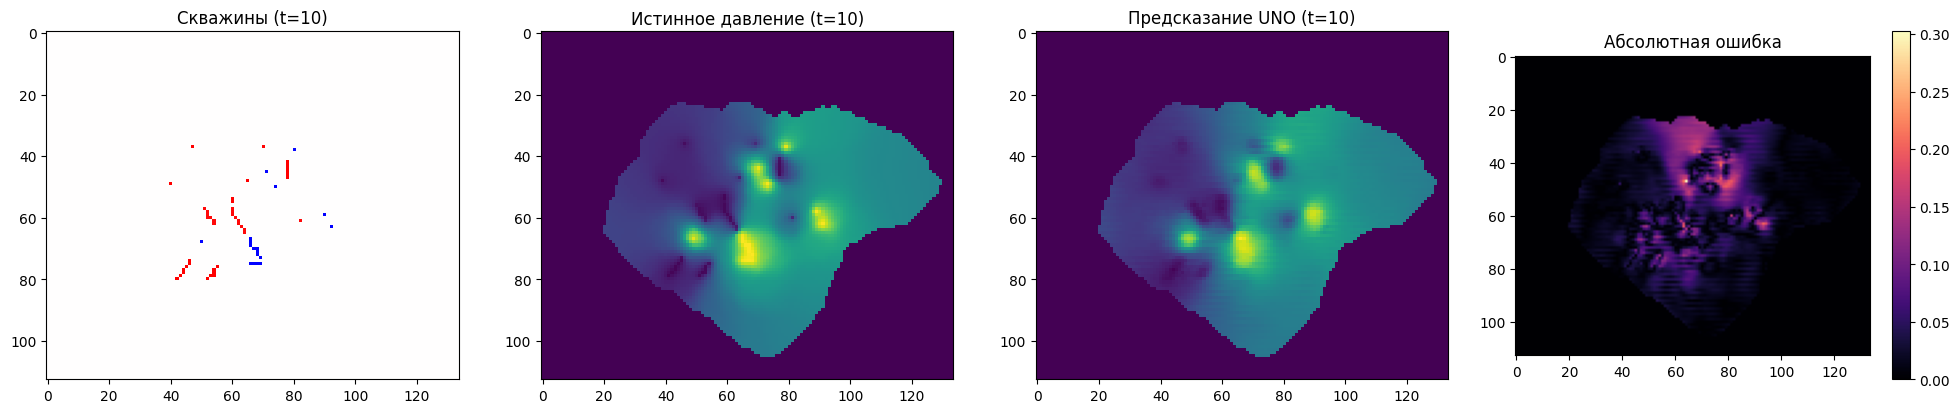

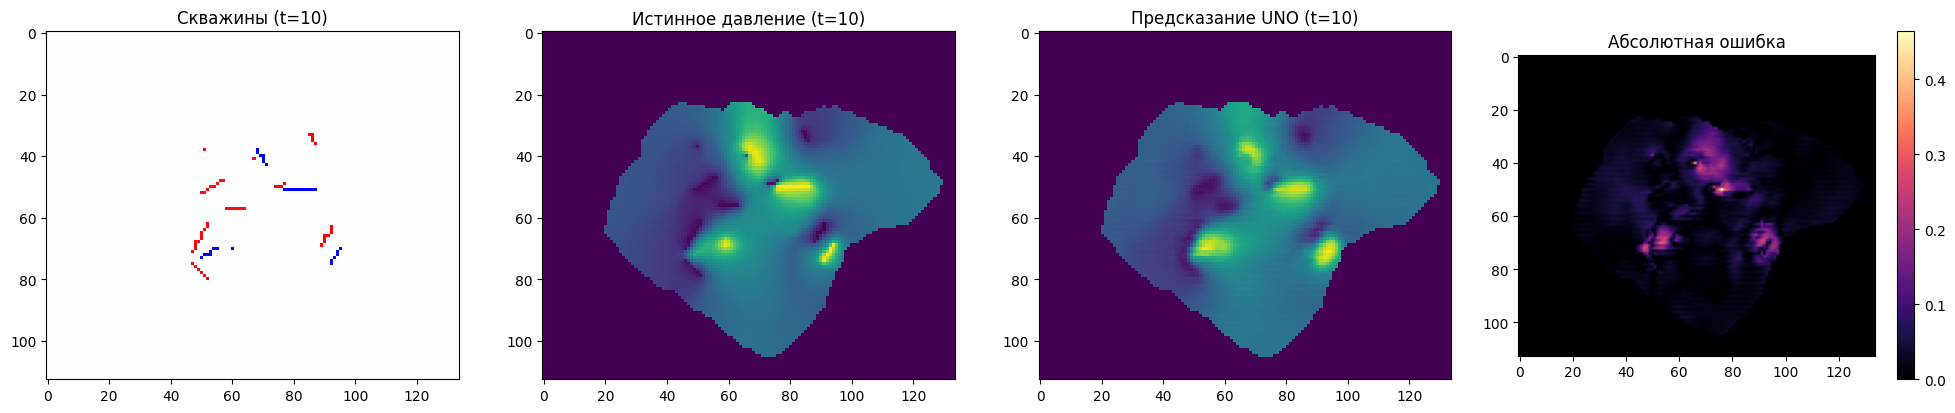

Средняя глобальная ошибка: 10.46%
Средняя ошибка В СКВАЖИНАХ: 15.70%


In [14]:
device = "cuda:1" if torch.cuda.is_available() else "cpu"

train_idx, val_idx, test_idx = get_indices(X_final.shape[0])

train_ds = SpatiotemporalDataset(X_final, train_idx)
val_ds = SpatiotemporalDataset(X_final, val_idx)
test_ds = SpatiotemporalDataset(X_final, test_idx)

BATCH_SIZE = 2 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

MODES_3D = [
    [8, 16, 16], 
    [8, 12, 12], 
    [8, 12, 12], 
    [8, 16, 16]
]

SCALINGS_3D = [
    [1.0, 0.5, 0.5], 
    [1.0, 0.5, 0.5], 
    [1.0, 2.0, 2.0], 
    [1.0, 2.0, 2.0]
]

OUT_CHANNELS_3D = [32, 64, 64, 32] 

EPOCHS = 150

best_model = train_model(
    MODES_3D, SCALINGS_3D, OUT_CHANNELS_3D,
    train_loader, val_loader,
    static_mask=STATIC_MASK,
    device=device, epochs=EPOCHS
)

analyze_results(best_model, test_loader, device, STATIC_MASK)

In [13]:
device = "cuda:1" if torch.cuda.is_available() else "cpu"

train_idx, val_idx, test_idx = get_indices(X_final.shape[0])

train_ds = SpatiotemporalDataset(X_final, train_idx)
val_ds = SpatiotemporalDataset(X_final, val_idx)
test_ds = SpatiotemporalDataset(X_final, test_idx)

BATCH_SIZE = 2 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

MODES_3D = [
    [8, 16, 16],
    [8, 12, 12], 
    [8, 12, 12],
    [8, 16, 16]
]

SCALINGS_3D = [
    [1.0, 0.5, 0.5], 
    [1.0, 0.5, 0.5],
    [1.0, 2.0, 2.0],
    [1.0, 2.0, 2.0]
]

OUT_CHANNELS_3D =[32, 64, 64, 32]

best_model_3d = UNO(
    in_channels=2, 
    out_channels=1,
    domain_padding=0.1,
    non_linearity=torch.nn.functional.gelu,
    hidden_channels=32, 
    n_layers=4,
    projection_channels=32,
    uno_out_channels=OUT_CHANNELS_3D,
    uno_n_modes=MODES_3D,
    uno_scalings=SCALINGS_3D,
    channel_mlp_skip="linear"
).to(device)

best_model_3d.load_state_dict(torch.load("uno_3d_best.pth", map_location=device))
best_model_3d.eval()

print("Модель загружена")

fno_skip='linear'
channel_mlp_skip='linear'
fno_skip='linear'
channel_mlp_skip='linear'
fno_skip='linear'
channel_mlp_skip='linear'
fno_skip='linear'
channel_mlp_skip='linear'
Модель загружена


In [ ]:
def generate_3d_gif(model, test_loader, device, static_mask, filename="uno_3d_rollout.gif"):
    model.eval()
    mask_np = static_mask.cpu().numpy()
    
    mask_3d = static_mask.to(device).float().unsqueeze(0).unsqueeze(0).unsqueeze(0)
    
    batch = next(iter(test_loader))
    x_in, y_true = [b.to(device) for b in batch]
    
    with torch.no_grad():
        pred = model(x_in)
        
        pred = pred * mask_3d
        y_true = y_true * mask_3d
        
    t0_true = x_in[0, 0, 0].cpu().numpy()
    true_fut = y_true[0, 0].cpu().numpy()
    pred_fut = pred[0, 0].cpu().numpy()
    
    wells_fut = x_in[0, 1].cpu().numpy()
    
    true_seq = np.concatenate([t0_true[np.newaxis, ...], true_fut], axis=0)
    pred_seq = np.concatenate([t0_true[np.newaxis, ...], pred_fut], axis=0)
    wells_seq = np.concatenate([wells_fut[0:1, ...], wells_fut], axis=0)
    
    T = true_seq.shape[0]
    
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    
    val_min = min(np.min(true_seq), np.min(pred_seq))
    val_max = max(np.max(true_seq), np.max(pred_seq))
    cbar_kwargs = {'fraction': 0.046, 'pad': 0.04}
    
    bounds =[0, 1, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100]
    cmap_error = plt.get_cmap('turbo')
    norm_error = mcolors.BoundaryNorm(bounds, cmap_error.N)
    
    im0 = axes[0].imshow(wells_seq[0], cmap='bwr')
    im1 = axes[1].imshow(true_seq[0], cmap='jet', vmin=val_min, vmax=val_max)
    im2 = axes[2].imshow(pred_seq[0], cmap='jet', vmin=val_min, vmax=val_max)
    im3 = axes[3].imshow(np.zeros_like(true_seq[0]), cmap=cmap_error, norm=norm_error)
    
    axes[0].set_title("Скважины (Source)", fontsize=14)
    axes[1].set_title("Истинное давление", fontsize=14)
    axes[2].set_title("Предсказание 3D UNO", fontsize=14)
    axes[3].set_title("Процентная ошибка (%)", fontsize=14)
    
    fig.colorbar(im0, ax=axes[0], **cbar_kwargs)
    fig.colorbar(im1, ax=axes[1], **cbar_kwargs)
    fig.colorbar(im2, ax=axes[2], **cbar_kwargs)
    fig.colorbar(im3, ax=axes[3], boundaries=bounds, ticks=bounds, spacing='uniform', **cbar_kwargs)
    
    for ax in axes: 
        ax.set_xticks([])
        ax.set_yticks([])
        
    time_text = fig.suptitle("Инициализация...", fontsize=16, fontweight='bold')

    def update(frame):
        im0.set_array(wells_seq[frame])
        im1.set_array(true_seq[frame])
        im2.set_array(pred_seq[frame])
        
        true_f, pred_f = true_seq[frame], pred_seq[frame]
        
        masked_true = true_f[mask_np > 0]
        max_t = np.max(np.abs(masked_true)) if len(masked_true) > 0 and np.max(np.abs(masked_true)) > 1e-8 else 1.0
        
        rel_err_map = np.zeros_like(true_f)
        rel_err_map[mask_np > 0] = np.clip((np.abs(true_f - pred_f)[mask_np > 0] / max_t) * 100, 0, 100)
        im3.set_array(rel_err_map)
        
        frame_err = (np.linalg.norm((pred_f - true_f) * mask_np) / (np.linalg.norm(true_f * mask_np) + 1e-8)) * 100
        
        step_lbl = "Начальное условие" if frame == 0 else f"Шаг {frame}/{T-1}"
        time_text.set_text(f"{step_lbl} | Глобальная L2 Ошибка: {frame_err:.2f}%")
        
        return [im0, im1, im2, im3, time_text]

    ani = animation.FuncAnimation(fig, update, frames=T, interval=250, blit=False)
    ani.save(filename, writer='pillow', fps=4)
    plt.close(fig)
    print(f"GIA сохранена как '{filename}'")

generate_3d_gif(
    model=best_model_3d, 
    test_loader=test_loader, 
    device=device, 
    static_mask=STATIC_MASK, 
    filename="uno_3d_rollout.gif"
)

GIA сохранена как 'uno_3d_rollout.gif'
